# 07 · GRU Model — Multi-step Forecast

**Project:** War Shocks & Global Financial Risk Spillover  
**Hyperparameters:** loaded from `outputs/best_params_gru.json`  
(selected by Optuna TPE, 30 trials, nb05b)  
**Features:** 8 rolling vol + VIX_level + Brent_ret + Gold_ret (11 total)  
**Horizons:** h = 1, 5, 10, 22 (direct multi-output)  
**Ref:** Kumar et al. (2024); Akiba et al. (2019)

In [ ]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import torch

from sklearn.preprocessing import MinMaxScaler
from src.data_loader import DATA_PROC_DIR
from src.var_models  import compute_metrics, compute_metrics_multistep, EQUITY_COLS, HORIZONS
from src.lstm_models import (
    build_multistep_sequences, build_loaders, 
    inverse_transform_vol, N_FEATURES, N_MARKETS,
)
from src.gru_models import VolatilityGRU, train_gru, predict_gru

SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIG_DIR   = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(TABLE_DIR, exist_ok=True)

TRAIN_START = "2006-01-01"; TRAIN_END = "2018-12-31"
VAL_START   = "2019-01-01"; VAL_END   = "2021-12-31"
TEST_START  = "2022-01-01"; TEST_END  = "2025-12-31"
SOLEIMANI_START = "2020-01-03"; SOLEIMANI_END = "2020-03-31"

print(f"Device : {DEVICE}")

Device : cpu


## 1 · Load Best Hyperparameters

In [2]:
param_path = os.path.join("..", "outputs", "best_params_gru.json")
with open(param_path) as f:
    best_params = json.load(f)

LOOKBACK    = best_params["lookback"]
HIDDEN_SIZE = best_params["hidden_size"]
N_LAYERS    = best_params["n_layers"]
DROPOUT     = best_params["dropout"]
LR          = best_params["lr"]
EPOCHS      = 50
PATIENCE    = 10
BATCH_SIZE  = 64

print(f"Best params from Optuna (nb05b):")
for k, v in best_params.items():
    print(f"  {k:15s}: {v}")

Best params from Optuna (nb05b):
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.1
  lr             : 0.01
  lookback       : 60


## 2 · Load & Build 11-Feature Matrix

In [3]:
vol_df   = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                 index_col=0, parse_dates=True)
war_df   = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                 index_col=0, parse_dates=True)
all_vars = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",
                 index_col=0, parse_dates=True)

controls = all_vars[["VIX", "Brent", "Gold"]].copy()
controls["Gold_ret"]  = np.log(controls["Gold"]  / controls["Gold"].shift(1))
controls["Brent_ret"] = np.log(controls["Brent"] / controls["Brent"].shift(1))
controls["VIX_level"] = controls["VIX"]
exog = controls[["VIX_level", "Brent_ret", "Gold_ret"]].shift(1)

common_idx  = vol_df.dropna().index
vol_clean   = vol_df.loc[common_idx, EQUITY_COLS]
exog_clean  = exog.reindex(common_idx).ffill(limit=3)
valid_mask  = exog_clean.notna().all(axis=1)
vol_clean   = vol_clean[valid_mask]
exog_clean  = exog_clean[valid_mask]
features_df = pd.concat([vol_clean, exog_clean], axis=1)

assert features_df.shape[1] == N_FEATURES
print(f"features_df: {features_df.shape}")
print(f"Date range : {features_df.index[0].date()} ~ {features_df.index[-1].date()}")

features_df: (4016, 11)
Date range : 2006-03-08 ~ 2025-12-30


## 3 · Split & Scale

In [4]:
feat_train = features_df.loc[TRAIN_START:TRAIN_END].values
feat_val   = features_df.loc[VAL_START:VAL_END].values
feat_test  = features_df.loc[TEST_START:TEST_END].values
val_dates  = features_df.loc[VAL_START:VAL_END].index
test_dates = features_df.loc[TEST_START:TEST_END].index

scaler = MinMaxScaler(feature_range=(0, 1))
feat_train_scaled = scaler.fit_transform(feat_train)
feat_val_scaled   = scaler.transform(feat_val)
feat_test_scaled  = scaler.transform(feat_test)

print(f"Train: {feat_train_scaled.shape}")
print(f"Val  : {feat_val_scaled.shape}")
print(f"Test : {feat_test_scaled.shape}")

Train: (2608, 11)
Val  : (594, 11)
Test : (814, 11)


## 4 · Build Multi-step Sequences

Direct multi-output: for each origin t, targets are vol at t+h for each h.  
Model is trained separately for each horizon h (direct strategy avoids  
error accumulation in recursive multi-step forecasting).

In [5]:
results_val_ms  = {}
results_test_ms = {}

for h in HORIZONS:
    print(f"Building sequences for h={h} ...")
    X_tr, Y_tr_dict, _ = build_multistep_sequences(
        feat_train_scaled, lookback=LOOKBACK, horizons=[h])
    X_vl, Y_vl_dict, vi = build_multistep_sequences(
        feat_val_scaled,   lookback=LOOKBACK, horizons=[h])
    X_te, Y_te_dict, ti = build_multistep_sequences(
        feat_test_scaled,  lookback=LOOKBACK, horizons=[h])

    y_tr = Y_tr_dict[h]; y_vl = Y_vl_dict[h]; y_te = Y_te_dict[h]
    val_seq_dates  = val_dates[vi]
    test_seq_dates = test_dates[ti]

    tr_ldr, vl_ldr = build_loaders(X_tr, y_tr, X_vl, y_vl, batch_size=BATCH_SIZE)

    # Initialise fresh model for each horizon
    model_h = VolatilityGRU(
        n_features=N_FEATURES, hidden_size=HIDDEN_SIZE,
        n_layers=N_LAYERS, dropout=DROPOUT, n_outputs=N_MARKETS
    ).to(DEVICE)

    print(f"  Training h={h} ...")
    model_h, history_h, best_ep_h = train_gru(
        model_h, tr_ldr, vl_ldr,
        epochs=EPOCHS, lr=LR, patience=PATIENCE,
        device=DEVICE, verbose=False
    )
    print(f"  h={h}: best_epoch={best_ep_h}  "
          f"best_val_loss={min(history_h['val_loss']):.6f}")

    # Forecasts
    from src.lstm_models import make_sequences as _ms
    preds_vl = predict_gru(model_h, X_vl, DEVICE)
    preds_te = predict_gru(model_h, X_te, DEVICE)

    fc_val  = pd.DataFrame(inverse_transform_vol(preds_vl, scaler),
                            index=val_seq_dates,  columns=EQUITY_COLS)
    act_val = pd.DataFrame(inverse_transform_vol(y_vl, scaler),
                            index=val_seq_dates,  columns=EQUITY_COLS)
    fc_test  = pd.DataFrame(inverse_transform_vol(preds_te, scaler),
                             index=test_seq_dates, columns=EQUITY_COLS)
    act_test = pd.DataFrame(inverse_transform_vol(y_te, scaler),
                             index=test_seq_dates, columns=EQUITY_COLS)

    results_val_ms[h]  = (act_val,  fc_val)
    results_test_ms[h] = (act_test, fc_test)

    # Save weights for largest model (h=1 is reference)
    if h == 1:
        torch.save(model_h.state_dict(),
                   os.path.join("..", "outputs", "gru_best_weights.pt"))

print("\nAll horizons trained.")

Building sequences for h=1 ...
  Training h=1 ...
  h=1: best_epoch=29  best_val_loss=0.000525
Building sequences for h=5 ...
  Training h=5 ...
  h=5: best_epoch=13  best_val_loss=0.002674
Building sequences for h=10 ...
  Training h=10 ...
  h=10: best_epoch=13  best_val_loss=0.006382
Building sequences for h=22 ...
  Training h=22 ...
  h=22: best_epoch=9  best_val_loss=0.018932

All horizons trained.


## 5 · Evaluation Metrics

In [6]:
metrics_val  = compute_metrics_multistep(results_val_ms,  label="GRU_Val")
metrics_test = compute_metrics_multistep(results_test_ms, label="GRU_Test")

print("=" * 65)
print("GRU METRICS — Validation (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_val[(metrics_val["Horizon"]==h) & (metrics_val["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

print("\n" + "=" * 65)
print("GRU METRICS — Test (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_test[(metrics_test["Horizon"]==h) & (metrics_test["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

GRU METRICS — Validation (AVERAGE across markets)
  h= 1: MSE=0.000381  MAE=0.0111  RMSE=0.0193  MAPE=6.14%  DirAcc=0.532
  h= 5: MSE=0.001965  MAE=0.0286  RMSE=0.0435  MAPE=15.90%  DirAcc=0.481
  h=10: MSE=0.004506  MAE=0.0434  RMSE=0.0650  MAPE=25.91%  DirAcc=0.492
  h=22: MSE=0.013839  MAE=0.0724  RMSE=0.1131  MAPE=41.83%  DirAcc=0.478

GRU METRICS — Test (AVERAGE across markets)
  h= 1: MSE=0.000270  MAE=0.0094  RMSE=0.0158  MAPE=6.17%  DirAcc=0.543
  h= 5: MSE=0.001611  MAE=0.0235  RMSE=0.0386  MAPE=14.92%  DirAcc=0.505
  h=10: MSE=0.003549  MAE=0.0384  RMSE=0.0577  MAPE=25.21%  DirAcc=0.496
  h=22: MSE=0.006932  MAE=0.0596  RMSE=0.0811  MAPE=42.45%  DirAcc=0.504


## 6 · Regime Breakdown (Val, h=1)

In [7]:
act_h1, fc_h1 = results_val_ms[1]
war_val    = war_df["mideast_war"].reindex(act_h1.index).fillna(0).astype(int)
crisis_val = war_df["any_crisis"].reindex(act_h1.index).fillna(0).astype(int)
sol_flag   = ((act_h1.index >= SOLEIMANI_START) & (act_h1.index <= SOLEIMANI_END))

regime_masks = {
    "B: War-Only"   : (war_val==1) & (crisis_val==0) & ~sol_flag,
    "D: War+Crisis" : (war_val==1) & (crisis_val==1) & ~sol_flag,
    "E: Sol/COVID"  : sol_flag,
}

print("=" * 65)
print("GRU CONDITIONAL METRICS — Val h=1 by Regime")
print("(A: Calm=0 obs; mideast_war=1 since 2011-03-15)")
print("=" * 65)

regime_results = {}
for name, mask in regime_masks.items():
    n = mask.sum()
    if n < 10:
        print(f"  {name}: {n} obs — skip"); continue
    m   = compute_metrics(act_h1[mask], fc_h1[mask], label=name)
    avg = m[m["Market"]=="AVERAGE"].iloc[0]
    print(f"  {name:25s} (n={n:4d}): "
          f"MSE={avg['MSE']:.6f}  RMSE={avg['RMSE']:.4f}  "
          f"MAPE={avg['MAPE']:.2f}%  DirAcc={avg['Dir_Acc']:.3f}")
    regime_results[name] = avg

if "B: War-Only" in regime_results and "D: War+Crisis" in regime_results:
    ratio = regime_results["D: War+Crisis"]["MSE"] / regime_results["B: War-Only"]["MSE"]
    print(f"\n  Crisis-on-war amplification ratio D/B (MSE) = {ratio:.3f}x")

GRU CONDITIONAL METRICS — Val h=1 by Regime
(A: Calm=0 obs; mideast_war=1 since 2011-03-15)
  B: War-Only               (n= 369): MSE=0.000157  RMSE=0.0124  MAPE=6.05%  DirAcc=0.531
  D: War+Crisis             (n= 127): MSE=0.000693  RMSE=0.0258  MAPE=5.82%  DirAcc=0.537
  E: Sol/COVID              (n=  37): MSE=0.001539  RMSE=0.0379  MAPE=8.06%  DirAcc=0.566

  Crisis-on-war amplification ratio D/B (MSE) = 4.421x


## 7 · Save Results

In [8]:
for h in HORIZONS:
    sub_val  = metrics_val[metrics_val["Horizon"]==h]
    sub_test = metrics_test[metrics_test["Horizon"]==h]
    pd.concat([sub_val, sub_test], ignore_index=True).to_excel(
        os.path.join(TABLE_DIR, f"table_gru_metrics_h{h}.xlsx"), index=False)

act_h1, fc_h1   = results_val_ms[1]
act_t1, fc_t1   = results_test_ms[1]
act_h1.to_excel(os.path.join(TABLE_DIR, "gru_actual_val.xlsx"))
fc_h1.to_excel(os.path.join(TABLE_DIR,  "gru_forecast_val.xlsx"))
act_t1.to_excel(os.path.join(TABLE_DIR, "gru_actual_test.xlsx"))
fc_t1.to_excel(os.path.join(TABLE_DIR,  "gru_forecast_test.xlsx"))
print(f"Saved all GRU metrics and forecasts.")

Saved all GRU metrics and forecasts.


## 8 · Fig 11 · GRU Forecast vs Actual (h=1)

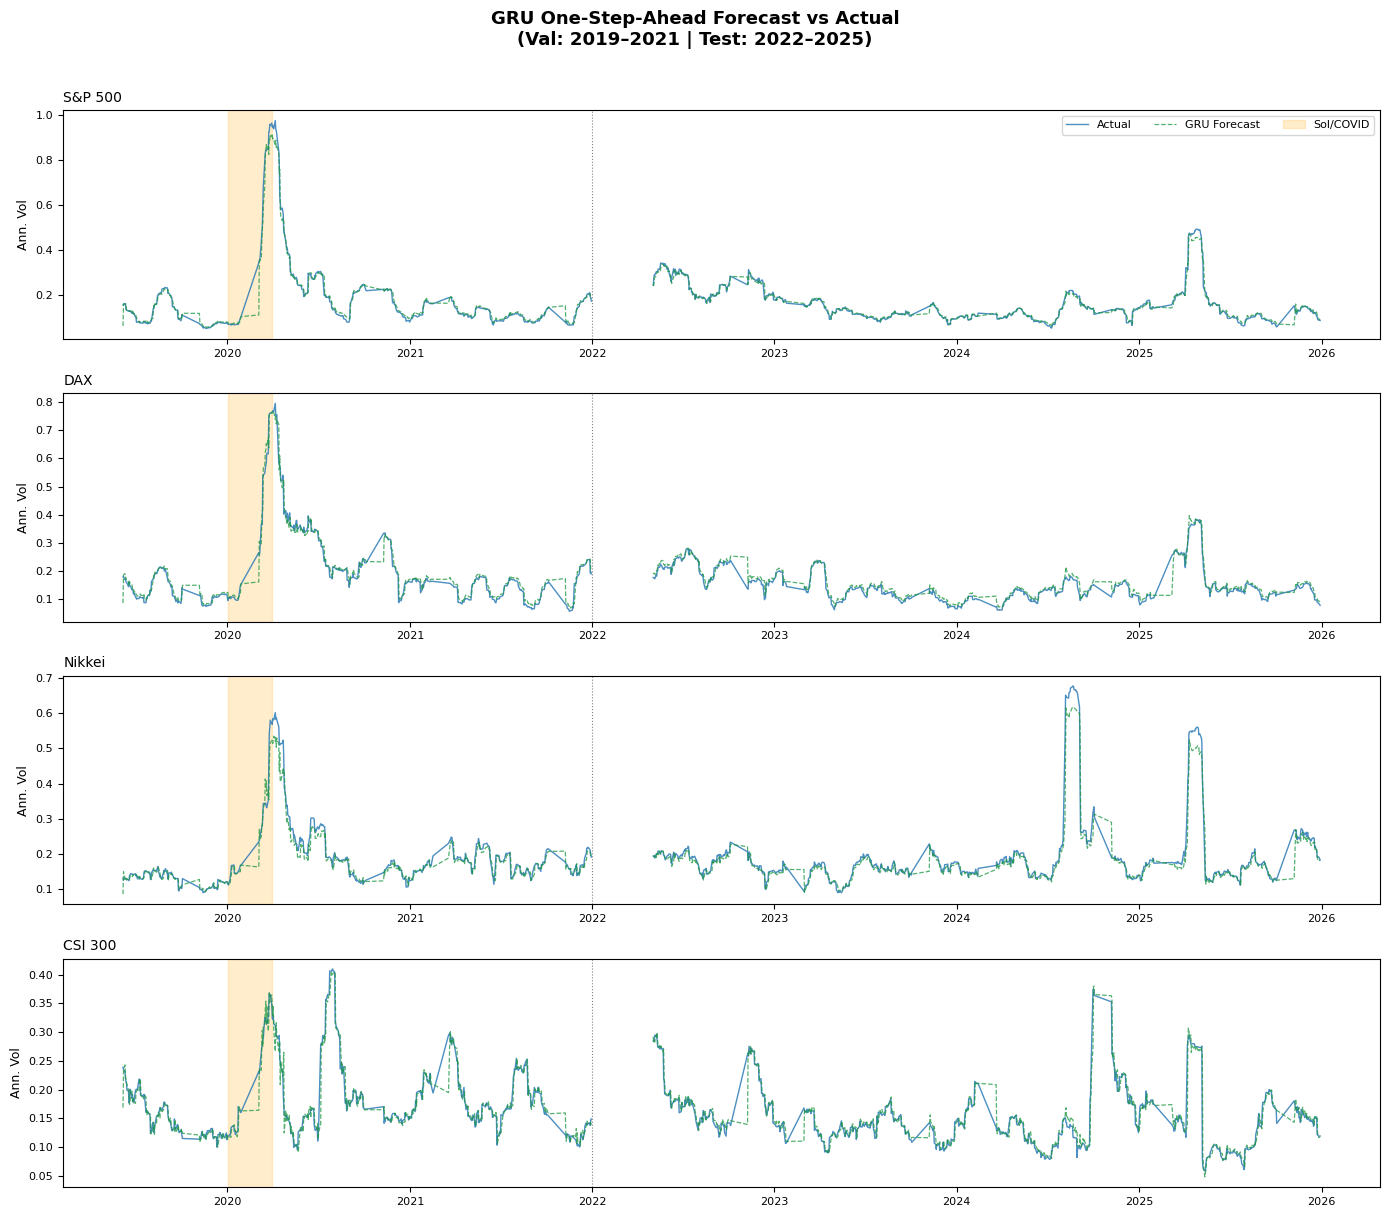

Saved → ..\outputs\figures\fig11_gru_forecast.png

Next → 07_results_comparison.ipynb


In [9]:
PLOT_MARKETS  = ["SP500_vol","DAX_vol","Nikkei_vol","CSI300_vol"]
MARKET_LABELS = ["S&P 500","DAX","Nikkei","CSI 300"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
fig.suptitle("GRU One-Step-Ahead Forecast vs Actual\n"
             "(Val: 2019–2021 | Test: 2022–2025)",
             fontsize=13, fontweight="bold", y=1.01)

act_v, fc_v = results_val_ms[1]
act_t, fc_t = results_test_ms[1]

for ax, col, label in zip(axes, PLOT_MARKETS, MARKET_LABELS):
    ax.plot(act_v.index, act_v[col], color="#2c7bb6", lw=1.0, alpha=0.85, label="Actual")
    ax.plot(fc_v.index,  fc_v[col],  color="#1a9641", lw=0.9, alpha=0.75,
            linestyle="--", label="GRU Forecast")
    ax.plot(act_t.index, act_t[col], color="#2c7bb6", lw=1.0, alpha=0.85)
    ax.plot(fc_t.index,  fc_t[col],  color="#1a9641", lw=0.9, alpha=0.75, linestyle="--")
    ax.axvspan(pd.Timestamp(SOLEIMANI_START), pd.Timestamp(SOLEIMANI_END),
               color="orange", alpha=0.2, label="Sol/COVID")
    ax.axvline(pd.Timestamp(TEST_START), color="gray", lw=0.8, linestyle=":")
    ax.set_ylabel("Ann. Vol", fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.tick_params(labelsize=8)
    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=8, ncol=3)

plt.tight_layout()
path = os.path.join(FIG_DIR, "fig11_gru_forecast.png")
plt.savefig(path, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {path}")
print("\nNext → 07_results_comparison.ipynb")